## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 40)

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# Path to raw data
RAW_DATA_PATH = Path('../data/raw/raw_data.xlsx')
TARGET = 'Churned'

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'Data path exists: {RAW_DATA_PATH.exists()}')

pandas  : 2.3.3
numpy   : 2.4.6
Data path exists: True


In [2]:
# Load all 3 sheets
df_demo = pd.read_excel(RAW_DATA_PATH, sheet_name='Demographic')
df_loc  = pd.read_excel(RAW_DATA_PATH, sheet_name='Location')
df_acc  = pd.read_excel(RAW_DATA_PATH, sheet_name='Account')

print('Sheet shapes loaded:')
print(f'  Demographic : {df_demo.shape}')
print(f'  Location    : {df_loc.shape}')
print(f'  Account     : {df_acc.shape}')

Sheet shapes loaded:
  Demographic : (10000, 7)
  Location    : (6, 2)
  Account     : (10000, 7)


In [3]:
# Verify all sheet names present in the file
xl = pd.ExcelFile(RAW_DATA_PATH)
print('Sheets in raw_data.xlsx:', xl.sheet_names)

Sheets in raw_data.xlsx: ['Demographic', 'Location', 'Account']


### Demographic

In [4]:
df_demo.head()

,CustomerId,Name,Gender,Age,Salary,LocationId,Churned
0,15634602,Hargrave,Female,42,101348.88,2,1
1,15647311,Hill,Female,41,112542.58,6,0
2,15619304,Onio,Female,42,113931.57,4,1
3,15701354,Boni,Female,39,93826.63,1,0
4,15737888,Mitchell,Female,43,79084.10,4,0


In [5]:
print('=== Demographic Sheet ===')
print(f'Shape       : {df_demo.shape}')
print(f'Columns     : {list(df_demo.columns)}')
print()
print('--- Data Types ---')
print(df_demo.dtypes)
print()
print('--- Missing Values ---')
missing = df_demo.isnull().sum()
pct     = (missing / len(df_demo) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Pct (%)': pct}))
print()
print(f'Duplicate rows: {df_demo.duplicated().sum()}')

=== Demographic Sheet ===
Shape       : (10000, 7)
Columns     : ['CustomerId', 'Name', 'Gender', 'Age', 'Salary', 'LocationId', 'Churned']

--- Data Types ---
CustomerId      int64
Name           object
Gender         object
Age             int64
Salary        float64
LocationId      int64
Churned         int64
dtype: object

--- Missing Values ---
            Missing  Pct (%)
CustomerId        0     0.00
Name              0     0.00
Gender            0     0.00
Age               0     0.00
Salary            0     0.00
LocationId        0     0.00
Churned           0     0.00

Duplicate rows: 0


In [6]:
# Statistical summary — numerical columns
df_demo.describe()

,CustomerId,Age,Salary,LocationId,Churned
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,15690940.57,38.92,100090.24,3.51,0.20
std,71936.19,10.49,57510.49,1.70,0.40
min,15565701.00,18.00,11.58,1.00,0.00
25%,15628528.25,32.00,51002.11,2.00,0.00
50%,15690738.00,37.00,100193.91,4.00,0.00
75%,15753233.75,44.00,149388.25,5.00,0.00
max,15815690.00,92.00,199992.48,6.00,1.00


In [7]:
# Categorical columns in Demographic
print('--- Categorical Column Cardinality ---')
for col in df_demo.select_dtypes('object').columns:
    print(f'\n{col} — {df_demo[col].nunique()} unique values')
    print(df_demo[col].value_counts().head(10).to_string())

--- Categorical Column Cardinality ---

Name — 2932 unique values
Name
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
Genovese    25
Yeh         25
Shih        25
Wright      24
Maclean     24

Gender — 2 unique values
Gender
Male      5457
Female    4543


In [8]:
# Data quality checks — Phase 2.2 from e2e guide
print('=== Data Quality Checks — Demographic ===')

# 1. String NaN variants
str_cols = df_demo.select_dtypes('object').columns
for col in str_cols:
    nan_variants = df_demo[col].isin(['NaN', 'nan', 'NA', 'null', 'NULL', '', ' ']).sum()
    print(f'[String NaN] {col}: {nan_variants} occurrences')

# 2. Age validity (must be 18–100)
invalid_age = df_demo[(df_demo['Age'] < 18) | (df_demo['Age'] > 100)].shape[0]
print(f'\n[Age] Values outside [18, 100]: {invalid_age}')
print(f'[Age] Min: {df_demo["Age"].min()}, Max: {df_demo["Age"].max()}, Mean: {df_demo["Age"].mean():.1f}')

# 3. Salary validity
invalid_salary = df_demo[df_demo['Salary'] <= 0].shape[0]
print(f'\n[Salary] Values <= 0: {invalid_salary}')
print(f'[Salary] Min: {df_demo["Salary"].min():.2f}, Max: {df_demo["Salary"].max():.2f}')

# 4. LocationId valid range (1–6, matching Location sheet)
print(f'\n[LocationId] Unique values: {sorted(df_demo["LocationId"].unique())}')

# 5. Churned must be binary
print(f'\n[Churned] Unique values: {sorted(df_demo["Churned"].unique())}')

=== Data Quality Checks — Demographic ===
[String NaN] Name: 0 occurrences
[String NaN] Gender: 0 occurrences

[Age] Values outside [18, 100]: 0
[Age] Min: 18, Max: 92, Mean: 38.9

[Salary] Values <= 0: 0
[Salary] Min: 11.58, Max: 199992.48

[LocationId] Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

[Churned] Unique values: [np.int64(0), np.int64(1)]


#### Location

In [9]:
# Small lookup table — show completely
print(f'Shape: {df_loc.shape}')
print()
display(df_loc)
print()
print(f'Dtypes:\n{df_loc.dtypes}')
print(f'\nMissing values: {df_loc.isnull().sum().sum()}')
print(f'Duplicate rows: {df_loc.duplicated().sum()}')

Shape: (6, 2)



,LocationId,Geography
0,1,Germany
1,2,France
2,3,Spain
3,4,UK
4,5,Canada
5,6,USA



Dtypes:
LocationId     int64
Geography     object
dtype: object

Missing values: 0
Duplicate rows: 0


In [10]:
# How many customers per Geography?
geo_counts = (
    df_demo
    .merge(df_loc, on='LocationId', how='left')
    ['Geography']
    .value_counts()
    .reset_index()
)
geo_counts.columns = ['Geography', 'CustomerCount']
geo_counts['Pct (%)'] = (geo_counts['CustomerCount'] / len(df_demo) * 100).round(2)
print('Customer distribution by Geography:')
display(geo_counts)

Customer distribution by Geography:


,Geography,CustomerCount,Pct (%)
0,France,1714,17.14
1,UK,1703,17.03
2,Canada,1679,16.79
3,USA,1669,16.69
4,Germany,1626,16.26
5,Spain,1609,16.09


### Account

In [11]:
df_acc.head()

,AccountId,CustomerId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
0,A15634602SID,15634602,2,NaN,1,1,1
1,A15647311SID,15647311,1,83807.86,1,0,1
2,A15619304SID,15619304,8,159660.80,3,1,0
3,A15701354SID,15701354,1,NaN,2,0,0
4,A15737888SID,15737888,2,125510.82,1,1,1


In [12]:
print('=== Account Sheet ===')
print(f'Shape       : {df_acc.shape}')
print(f'Columns     : {list(df_acc.columns)}')
print()
print('--- Data Types ---')
print(df_acc.dtypes)
print()
print('--- Missing Values ---')
missing_acc = df_acc.isnull().sum()
pct_acc     = (missing_acc / len(df_acc) * 100).round(2)
print(pd.DataFrame({'Missing': missing_acc, 'Pct (%)': pct_acc}))
print()
print(f'Duplicate rows: {df_acc.duplicated().sum()}')

=== Account Sheet ===
Shape       : (10000, 7)
Columns     : ['AccountId', 'CustomerId', 'Tenure', 'Balance', 'NumProducts', 'HasCreditCard', 'IsActive']

--- Data Types ---
AccountId         object
CustomerId         int64
Tenure             int64
Balance          float64
NumProducts        int64
HasCreditCard      int64
IsActive           int64
dtype: object

--- Missing Values ---
               Missing  Pct (%)
AccountId            0     0.00
CustomerId           0     0.00
Tenure               0     0.00
Balance           3617    36.17
NumProducts          0     0.00
HasCreditCard        0     0.00
IsActive             0     0.00

Duplicate rows: 0


In [13]:
df_acc.describe()

,CustomerId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
count,10000.00,10000.00,6383.00,10000.00,10000.00,10000.00
mean,15690940.57,5.01,119827.49,1.53,0.71,0.52
std,71936.19,2.89,30095.06,0.58,0.46,0.50
min,15565701.00,0.00,3768.69,1.00,0.00,0.00
25%,15628528.25,3.00,100181.98,1.00,0.00,0.00
50%,15690738.00,5.00,119839.69,1.00,1.00,1.00
75%,15753233.75,7.00,139512.29,2.00,1.00,1.00
max,15815690.00,10.00,250898.09,4.00,1.00,1.00


In [14]:
print('=== Data Quality Checks — Account ===')

# NumProducts valid range (1–4)
print(f'[NumProducts] Unique values: {sorted(df_acc["NumProducts"].unique())}')
invalid_products = df_acc[~df_acc['NumProducts'].isin([1, 2, 3, 4])].shape[0]
print(f'[NumProducts] Values outside [1, 4]: {invalid_products}')

# HasCreditCard must be binary
print(f'\n[HasCreditCard] Unique values: {sorted(df_acc["HasCreditCard"].unique())}')

# IsActive must be binary
print(f'[IsActive] Unique values: {sorted(df_acc["IsActive"].unique())}')

# Tenure range (0–10)
print(f'\n[Tenure] Min: {df_acc["Tenure"].min()}, Max: {df_acc["Tenure"].max()}')

# Balance — missing values
balance_missing = df_acc['Balance'].isnull().sum()
balance_pct     = balance_missing / len(df_acc) * 100
print(f'\n[Balance] Missing: {balance_missing} ({balance_pct:.2f}%) ⚠️ HIGH MISSINGNESS')
print(f'[Balance] Min: {df_acc["Balance"].min():.2f}, Max: {df_acc["Balance"].max():.2f}')
print(f'[Balance] Median: {df_acc["Balance"].median():.2f}')

# AccountId uniqueness
print(f'\n[AccountId] Unique: {df_acc["AccountId"].nunique()} / {len(df_acc)} (100% unique = identifier ✅)')

=== Data Quality Checks — Account ===
[NumProducts] Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[NumProducts] Values outside [1, 4]: 0

[HasCreditCard] Unique values: [np.int64(0), np.int64(1)]
[IsActive] Unique values: [np.int64(0), np.int64(1)]

[Tenure] Min: 0, Max: 10

[Balance] Missing: 3617 (36.17%) ⚠️ HIGH MISSINGNESS
[Balance] Min: 3768.69, Max: 250898.09
[Balance] Median: 119839.69

[AccountId] Unique: 10000 / 10000 (100% unique = identifier ✅)


In [15]:
print('=== Relational Integrity Checks ===')

# Check 1: All LocationIds in Demographic exist in Location
demo_loc_ids = set(df_demo['LocationId'].unique())
loc_ids      = set(df_loc['LocationId'].unique())
orphaned_loc = demo_loc_ids - loc_ids
print(f'Demographic LocationIds    : {sorted(demo_loc_ids)}')
print(f'Location LocationIds       : {sorted(loc_ids)}')
print(f'Orphaned LocationIds       : {orphaned_loc} (should be empty set)')

print()

# Check 2: All CustomerId in Demographic exist in Account
demo_cids = set(df_demo['CustomerId'].unique())
acc_cids  = set(df_acc['CustomerId'].unique())
orphaned_demo = demo_cids - acc_cids
orphaned_acc  = acc_cids - demo_cids
print(f'Demographic CustomerId count : {len(demo_cids)}')
print(f'Account CustomerId count     : {len(acc_cids)}')
print(f'In Demographic NOT in Account: {len(orphaned_demo)} (should be 0)')
print(f'In Account NOT in Demographic: {len(orphaned_acc)} (should be 0)')

=== Relational Integrity Checks ===
Demographic LocationIds    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Location LocationIds       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Orphaned LocationIds       : set() (should be empty set)

Demographic CustomerId count : 10000
Account CustomerId count     : 10000
In Demographic NOT in Account: 0 (should be 0)
In Account NOT in Demographic: 0 (should be 0)


In [16]:
# Execute the relational join
df_merged = (
    df_demo
    .merge(df_loc, on='LocationId', how='left')   # Bring in Geography
    .merge(df_acc, on='CustomerId', how='left')   # Bring in Account info
)

print(f'Post-join shape: {df_merged.shape}')
print(f'Expected       : (10000, 14)')
assert df_merged.shape[0] == len(df_demo), 'Row count changed after merge!'
print('\nJoin integrity: ✅ Row count preserved')
df_merged.head(3)

Post-join shape: (10000, 14)
Expected       : (10000, 14)

Join integrity: ✅ Row count preserved


,CustomerId,Name,Gender,Age,Salary,LocationId,Churned,Geography,AccountId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
0,15634602,Hargrave,Female,42,101348.88,2,1,France,A15634602SID,2,NaN,1,1,1
1,15647311,Hill,Female,41,112542.58,6,0,USA,A15647311SID,1,83807.86,1,0,1
2,15619304,Onio,Female,42,113931.57,4,1,UK,A15619304SID,8,159660.80,3,1,0


### Merged data view

In [17]:
print('=== Combined Dataset (Post-Join) ===')
print(f'Shape   : {df_merged.shape}')
print(f'Columns : {list(df_merged.columns)}')
print()
print('--- Data Types ---')
print(df_merged.dtypes)
print()
print('--- Missing Values (All Columns) ---')
missing_m = df_merged.isnull().sum()
pct_m     = (missing_m / len(df_merged) * 100).round(2)
mv_df     = pd.DataFrame({'Missing': missing_m, 'Pct (%)': pct_m})
print(mv_df[mv_df['Missing'] > 0])
print(f'\nColumns with zero missing: {(mv_df["Missing"] == 0).sum()} / {len(mv_df)}')

=== Combined Dataset (Post-Join) ===
Shape   : (10000, 14)
Columns : ['CustomerId', 'Name', 'Gender', 'Age', 'Salary', 'LocationId', 'Churned', 'Geography', 'AccountId', 'Tenure', 'Balance', 'NumProducts', 'HasCreditCard', 'IsActive']

--- Data Types ---
CustomerId         int64
Name              object
Gender            object
Age                int64
Salary           float64
LocationId         int64
Churned            int64
Geography         object
AccountId         object
Tenure             int64
Balance          float64
NumProducts        int64
HasCreditCard      int64
IsActive           int64
dtype: object

--- Missing Values (All Columns) ---
         Missing  Pct (%)
Balance     3617    36.17

Columns with zero missing: 13 / 14


In [18]:
df_merged.describe(include='all')

,CustomerId,Name,Gender,Age,Salary,LocationId,Churned,Geography,AccountId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
count,10000.00,10000,10000,10000.00,10000.00,10000.00,10000.00,10000,10000,10000.00,6383.00,10000.00,10000.00,10000.00
unique,NaN,2932,2,NaN,NaN,NaN,NaN,6,10000,NaN,NaN,NaN,NaN,NaN
top,NaN,Smith,Male,NaN,NaN,NaN,NaN,France,A15634602SID,NaN,NaN,NaN,NaN,NaN
freq,NaN,32,5457,NaN,NaN,NaN,NaN,1714,1,NaN,NaN,NaN,NaN,NaN
mean,15690940.57,NaN,NaN,38.92,100090.24,3.51,0.20,NaN,NaN,5.01,119827.49,1.53,0.71,0.52
std,71936.19,NaN,NaN,10.49,57510.49,1.70,0.40,NaN,NaN,2.89,30095.06,0.58,0.46,0.50
min,15565701.00,NaN,NaN,18.00,11.58,1.00,0.00,NaN,NaN,0.00,3768.69,1.00,0.00,0.00
25%,15628528.25,NaN,NaN,32.00,51002.11,2.00,0.00,NaN,NaN,3.00,100181.98,1.00,0.00,0.00
50%,15690738.00,NaN,NaN,37.00,100193.91,4.00,0.00,NaN,NaN,5.00,119839.69,1.00,1.00,1.00
75%,15753233.75,NaN,NaN,44.00,149388.25,5.00,0.00,NaN,NaN,7.00,139512.29,2.00,1.00,1.00


### Target

In [19]:
churn_counts = df_merged[TARGET].value_counts()
churn_pct    = df_merged[TARGET].value_counts(normalize=True) * 100

print('=== Target: Churned ===')
print(f'0 = Stayed : {churn_counts[0]:,} ({churn_pct[0]:.2f}%)')
print(f'1 = Churned: {churn_counts[1]:,} ({churn_pct[1]:.2f}%)')
print(f'\nClass imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1  ⚠️ Imbalanced')

=== Target: Churned ===
0 = Stayed : 7,963 (79.63%)
1 = Churned: 2,037 (20.37%)

Class imbalance ratio: 3.9:1  ⚠️ Imbalanced


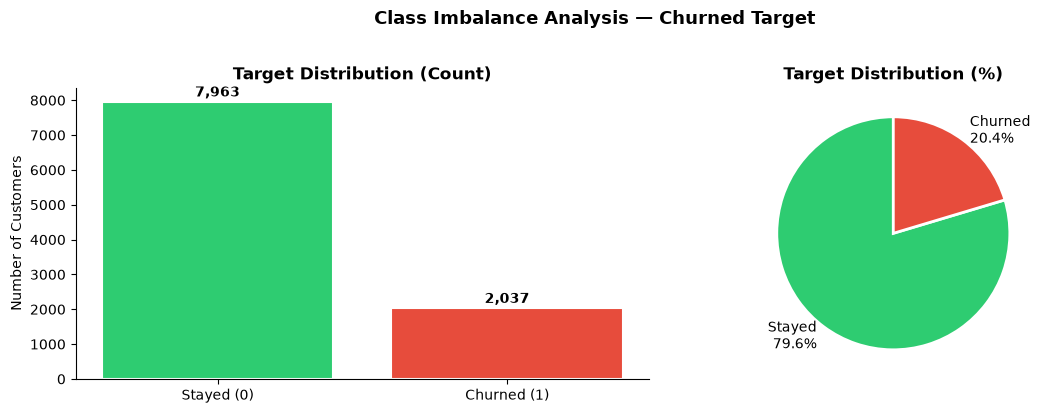


⚠️ Imbalanced dataset: requires class_weight="balanced" or scale_pos_weight in models


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Target Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(churn_counts.values,
            labels=[f'Stayed\n{churn_pct[0]:.1f}%', f'Churned\n{churn_pct[1]:.1f}%'],
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Distribution (%)', fontweight='bold')

plt.suptitle('Class Imbalance Analysis — Churned Target', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n⚠️ Imbalanced dataset: requires class_weight="balanced" or scale_pos_weight in models')